# spaLLM Lymph Node Workflow (Kaggle Standalone Version)
This notebook contains **ALL** the source code for spaLLM built directly into the notebook cells. You do **not** need to upload the codebase as a separate dataset!

**Requirements to Attach:**
1. **scGPT Model Dataset** (e.g., `scgpt-human`)
2. **Lymph Node Dataset** (e.g., `lymph-node-data`) - containing `adata_RNA.h5ad`, `adata_ADT.h5ad`, and `annotation.csv`.

**Before running:** Turn on the **GPU (T4 x2 or P100)** in the Kaggle session settings.

In [1]:
# Install dependencies (Kaggle & Colab compatible)
# 1. Force install PyPI torch, torchvision, and torchtext FIRST (This silently upgrades numpy to 2.x!)
!pip install -q torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 torchtext==0.18.0

# 2. SCORCHED EARTH: Now we nuke whatever numpy/scipy versions torch just pulled
!pip uninstall -y numpy scipy scikit-learn pandas scanpy anndata datasets
!rm -rf /usr/local/lib/python3.12/dist-packages/numpy*
!rm -rf /usr/local/lib/python3.12/dist-packages/scipy*

# 3. Force the strictly compatible Spring 2024 Stack LAST so pip can't touch it!
!pip install -q "numpy==1.26.4" "scipy==1.13.1" "scikit-learn==1.4.2" "pandas==2.2.2"

# 4. Install omics libraries
!pip install -q scanpy anndata datasets scikit-misc leidenalg louvain

# 5. Install scGPT safely without touching PyTorch
!pip install -q scgpt==0.2.4 --no-deps


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/19

In [2]:
# --- COMBINED spaLLM SOURCE CODE ---
import os
import random
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn.functional as F
from torch.nn.parameter import Parameter
from torch.nn.modules.module import Module
from torch.backends import cudnn
import sklearn
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from scipy.sparse import coo_matrix
import anndata as ad
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import Optional

# 1. modelTriatt_Flow1.py
import torch
import torch.nn.functional as F
from torch.nn.parameter import Parameter
from torch.nn.modules.module import Module

def init_weights(*params):
    """Initialize weights with Xavier uniform distribution."""
    for param in params:
        torch.nn.init.xavier_uniform_(param)

class DeepEncoder(Module):
    """Modality-specific GNN encoder."""
    def __init__(self, in_feat, out_feat, dropout=0.0, act=F.relu):
        super().__init__()
        self.dropout = dropout
        self.act = act
        self.hidden_dim = out_feat * 2

        self.weights = torch.nn.ParameterList([
            Parameter(torch.FloatTensor(in_feat, self.hidden_dim)),
            Parameter(torch.FloatTensor(self.hidden_dim, self.hidden_dim)),
            Parameter(torch.FloatTensor(self.hidden_dim, out_feat))
        ])
        init_weights(*self.weights)

    def forward(self, feat, adj):
        x = self._apply_layer(feat, adj, self.weights[0])
        x = self._apply_layer(x, adj, self.weights[1])
        x = torch.spmm(adj, torch.mm(x, self.weights[2]))
        return x

    def _apply_layer(self, x, adj, weight):
        x = torch.spmm(adj, torch.mm(x, weight))
        x = self.act(x)
        return F.dropout(x, self.dropout, training=self.training)

class CellEmbedding(Module):
    """Modality-specific cell embedding encoder/decoder."""
    def __init__(self, in_feat, out_feat):
        super().__init__()
        self.weight = Parameter(torch.FloatTensor(in_feat, out_feat))
        init_weights(self.weight)

    def forward(self, feat, adj):
        return torch.spmm(adj, torch.mm(feat, self.weight))

class AttentionLayer(Module):
    """Generic Attention Layer."""
    def __init__(self, in_feat, out_feat):
        super().__init__()
        self.w_omega = Parameter(torch.FloatTensor(in_feat, out_feat))
        self.u_omega = Parameter(torch.FloatTensor(out_feat, 1))
        init_weights(self.w_omega, self.u_omega)

    def forward(self, *embeddings):
        emb_stack = torch.cat([torch.unsqueeze(emb, dim=1) for emb in embeddings], dim=1)
        v = torch.tanh(torch.matmul(emb_stack, self.w_omega))
        vu = torch.matmul(v, self.u_omega)
        alpha = F.softmax(vu.squeeze(-1) + 1e-6, dim=1)
        emb_combined = torch.matmul(emb_stack.transpose(1, 2), alpha.unsqueeze(-1)).squeeze(-1)
        return emb_combined, alpha

class EncodingNetwork(Module):
    """Encoding network with modality-specific encoders, decoders, and attention layers."""
    def __init__(self, dim_in_omics1, dim_out_omics1, dim_in_omics2, dim_out_omics2):
        super().__init__()
        self.encoder_embedding = CellEmbedding(512, 64)
        self.decoder_embedding = CellEmbedding(64, 512)

        self.encoder_omics1 = DeepEncoder(dim_in_omics1, dim_out_omics1)
        self.decoder_omics1 = DeepEncoder(dim_out_omics1, dim_in_omics1)
        self.encoder_omics2 = DeepEncoder(dim_in_omics2, dim_out_omics2)
        self.decoder_omics2 = DeepEncoder(dim_out_omics2, dim_in_omics2)

        self.atten_feature1 = AttentionLayer(dim_out_omics1, dim_out_omics1)
        self.atten_feature2 = AttentionLayer(dim_out_omics1, dim_out_omics1)
        self.atten_feature = AttentionLayer(dim_out_omics1, dim_out_omics1)
        self.atten_omics2 = AttentionLayer(dim_out_omics2, dim_out_omics2)
        self.atten_cross = AttentionLayer(dim_out_omics1, dim_out_omics2)

    def forward(self, f_omics1, f_omics2, adj_spa1, adj_fea1, adj_spa2, adj_fea2, cell_emb, adj_emb):
        emb_spa = self.encoder_embedding(cell_emb, adj_spa1)
        emb_fea = self.encoder_embedding(cell_emb, adj_emb)

        emb_latent_spa1 = self.encoder_omics1(f_omics1, adj_spa1)
        emb_latent_spa2 = self.encoder_omics2(f_omics2, adj_spa2)
        emb_latent_fea1 = self.encoder_omics1(f_omics1, adj_fea1)
        emb_latent_fea2 = self.encoder_omics2(f_omics2, adj_fea2)

        emb_att1, alpha_att1 = self.atten_feature1(emb_spa, emb_latent_spa1)
        emb_att2, alpha_att2 = self.atten_feature2(emb_fea, emb_latent_fea1)
        emb_latent_omics1, alpha_att_omics1 = self.atten_feature(emb_att1, emb_att2)
        emb_latent_omics2, alpha_omics2 = self.atten_omics2(emb_latent_spa2, emb_latent_fea2)

        emb_latent_combined, alpha = self.atten_cross(emb_latent_omics1, emb_latent_omics2)

        emb_recon1 = self.decoder_omics1(emb_latent_combined, adj_spa1)
        emb_recon2 = self.decoder_omics2(emb_latent_combined, adj_spa2)
        emb_recon_spa = self.decoder_embedding(emb_spa, adj_spa1)
        emb_recon_fea = self.decoder_embedding(emb_fea, adj_emb)

        emb_cross1 = self.encoder_omics2(self.decoder_omics2(emb_latent_omics1, adj_spa2), adj_spa2)
        emb_cross2 = self.encoder_omics1(self.decoder_omics1(emb_latent_omics2, adj_spa1), adj_spa1)

        return {
            'emb_latent_omics1': emb_latent_omics1, 'emb_latent_omics2': emb_latent_omics2,
            'emb_latent_combined': emb_latent_combined, 'emb_recon_omics1': emb_recon1, 'emb_recon_omics2': emb_recon2,
            'emb_cross1': emb_cross1, 'emb_cross2': emb_cross2,
            'alpha_att1': alpha_att1, 'alpha_att2': alpha_att2, 'alpha_omics1': alpha_att_omics1,
            'alpha_omics2': alpha_omics2, 'alpha': alpha, 'emb_recon_spa': emb_recon_spa,
            'emb_recon_fea': emb_recon_fea
        }


# 2. preprocess.py
import os
import random
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import sklearn
from scipy.sparse import coo_matrix
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from torch.backends import cudnn
from typing import Optional
import anndata as ad

def fix_seed(seed: int):
    """Fix random seed for reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False

def construct_neighbor_graph(adata_omics1, adata_omics2, datatype='SPOTS', n_neighbors=3):
    """Construct spatial and feature neighbor graphs."""
    if datatype == 'Spatial-epigenome-transcriptome':
        n_neighbors = 6

    def _construct_spatial_graph(adata):
        cell_position = adata.obsm['spatial']
        return construct_graph_by_coordinate(cell_position, n_neighbors)

    adata_omics1.uns['adj_spatial'] = _construct_spatial_graph(adata_omics1)
    adata_omics2.uns['adj_spatial'] = _construct_spatial_graph(adata_omics2)

    adata_omics1.obsm['adj_feature'], adata_omics2.obsm['adj_feature'] = construct_graph_by_feature(
        adata_omics1, adata_omics2
    )
    return {'adata_omics1': adata_omics1, 'adata_omics2': adata_omics2}

def pca(adata: ad.AnnData, use_reps=None, n_comps=10):
    """Perform PCA for dimensionality reduction."""
    pca_model = PCA(n_components=n_comps)
    data = adata.obsm[use_reps] if use_reps else adata.X
    data = data.toarray() if sp.issparse(data) else data
    return pca_model.fit_transform(data)

def clr_normalize_each_cell(adata: ad.AnnData, inplace=True):
    """Normalize count vector for each cell using CLR normalization."""
    def seurat_clr(x):
        s = np.sum(np.log1p(x[x > 0]))
        exp = np.exp(s / len(x))
        return np.log1p(x / exp)

    if not inplace:
        adata = adata.copy()
    adata.X = np.apply_along_axis(
        seurat_clr, 1, adata.X.toarray() if sp.issparse(adata.X) else np.array(adata.X)
    )
    return adata

def construct_graph_by_feature(adata_omics1, adata_omics2, k=20, mode="connectivity", metric="correlation"):
    """Construct feature neighbor graphs based on expression profiles."""
    graph_omics1 = kneighbors_graph(adata_omics1.obsm['feat'], k, mode=mode, metric=metric, include_self=False)
    graph_omics2 = kneighbors_graph(adata_omics2.obsm['feat'], k, mode=mode, metric=metric, include_self=False)
    return graph_omics1, graph_omics2

def construct_graph_by_coordinate(cell_position, n_neighbors=3):
    """Construct spatial graph based on spatial coordinates."""
    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(cell_position)
    _, indices = nbrs.kneighbors(cell_position)
    x = indices[:, 0].repeat(n_neighbors)
    y = indices[:, 1:].flatten()
    return pd.DataFrame({'x': x, 'y': y, 'value': 1})

def transform_adjacent_matrix(adj_df):
    """Transform adjacency dataframe into sparse matrix."""
    n_spot = adj_df['x'].max() + 1
    return coo_matrix((adj_df['value'], (adj_df['x'], adj_df['y'])), shape=(n_spot, n_spot))

def preprocess_graph(adj):
    """Normalize adjacency matrix for GNN input."""
    adj = sp.coo_matrix(adj + sp.eye(adj.shape[0]))
    rowsum = np.array(adj.sum(1))
    degree_inv_sqrt = sp.diags(np.power(rowsum, -0.5).flatten())
    return sparse_mx_to_torch_sparse_tensor(adj.dot(degree_inv_sqrt).T.dot(degree_inv_sqrt))

def sparse_mx_to_torch_sparse_tensor(sparse_mx):
    """Convert scipy sparse matrix to torch sparse tensor."""
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    return torch.sparse.FloatTensor(indices, torch.from_numpy(sparse_mx.data), torch.Size(sparse_mx.shape))

def adjacent_matrix_preprocessing(adata_omics1, adata_omics2, adj_emb):
    """Preprocess spatial and feature adjacency matrices for GNNs."""
    def _process_adj(adj):
        adj = adj.toarray() + adj.toarray().T
        adj = np.where(adj > 1, 1, adj)
        return preprocess_graph(adj)

    adj_spatial_omics1 = _process_adj(transform_adjacent_matrix(adata_omics1.uns['adj_spatial']))
    adj_spatial_omics2 = _process_adj(transform_adjacent_matrix(adata_omics2.uns['adj_spatial']))
    adj_emb = _process_adj(adj_emb)

    def _process_feature_adj(adj):
        adj = adj + adj.T
        return preprocess_graph(np.where(adj > 1, 1, adj))

    adj_feature_omics1 = _process_feature_adj(torch.FloatTensor(adata_omics1.obsm['adj_feature'].toarray()))
    adj_feature_omics2 = _process_feature_adj(torch.FloatTensor(adata_omics2.obsm['adj_feature'].toarray()))

    return {
        'adj_spatial_omics1': adj_spatial_omics1,
        'adj_spatial_omics2': adj_spatial_omics2,
        'adj_feature_omics1': adj_feature_omics1,
        'adj_feature_omics2': adj_feature_omics2,
        'adj_emb': adj_emb
    }

def lsi(adata: ad.AnnData, n_components: int = 20, use_highly_variable: Optional[bool] = None, **kwargs):
    """LSI analysis (Seurat v3 approach)."""
    use_highly_variable = use_highly_variable if use_highly_variable is not None else "highly_variable" in adata.var
    adata_use = adata[:, adata.var["highly_variable"]] if use_highly_variable else adata
    X_norm = sklearn.preprocessing.Normalizer(norm="l1").fit_transform(tfidf(adata_use.X))
    X_lsi = sklearn.utils.extmath.randomized_svd(np.log1p(X_norm * 1e4), n_components, **kwargs)[0]
    adata.obsm["X_lsi"] = (X_lsi - X_lsi.mean(axis=1, keepdims=True)) / X_lsi.std(axis=1, ddof=1, keepdims=True)

def tfidf(X):
    """TF-IDF normalization following Seurat v3 approach."""
    idf = X.shape[0] / X.sum(axis=0)
    tf = X.multiply(1 / X.sum(axis=1)) if sp.issparse(X) else X / X.sum(axis=1, keepdims=True)
    return tf.multiply(idf) if sp.issparse(X) else tf * idf


# 3. utils.py
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch


try:
    import rpy2.robjects as robjects
    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
except Exception as e:
    robjects = None
    print(f"Warning: R environment not found or rpy2 error. R-based functionality like mclust will not be available.")

def convert_csv_to_h5ad(input_path, output_path):
    """Convert a CSV file to AnnData h5ad format."""
    data = pd.read_csv(input_path, index_col=0)
    obs_data = data.iloc[:, :2]
    obs_data.columns = ['barcode', 'assigned_cluster']

    expr_data = data.iloc[:, 2:].values.astype('float32')
    gene_names = data.columns[2:]

    adata = sc.AnnData(X=expr_data)
    adata.obs = obs_data
    adata.var['gene_names'] = gene_names
    adata.write(output_path)
    print(f"Data saved to {output_path}")

def convert_tsv_to_csv(tsv_path, csv_path):
    """Convert a TSV file to CSV format."""
    data = pd.read_csv(tsv_path, sep='\t')
    data.to_csv(csv_path, index=False)
    print(f"TSV file converted to CSV and saved at {csv_path}")

def create_h5ad_from_sparse_csv(input_csv, output_h5ad):
    """Create an AnnData h5ad file from a sparse matrix CSV file."""
    import scipy.sparse as sp
    import anndata as ad

    data = pd.read_csv(input_csv, index_col=0)
    expression_matrix = sp.csr_matrix(data.values)

    spatial_coords = data.index.str.split('x').tolist()
    spatial_coords = np.array(spatial_coords, dtype=int)

    adata = ad.AnnData(X=expression_matrix)
    adata.obsm['spatial'] = spatial_coords
    adata.var['gene_names'] = data.columns.values

    adata.write(output_h5ad)
    print(f"Sparse AnnData file saved to {output_h5ad}")

def mclust_R(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=2020):
    """Perform clustering using the R `mclust` algorithm."""
    if robjects is None:
        raise ImportError("rpy2 or R environment not found. Ensure R is installed and rpy2 is correctly configured.")
    
    robjects.r.library("mclust")
    robjects.r['set.seed'](random_seed)
    res = robjects.r['Mclust'](rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    adata.obs['mclust'] = np.array(res[-2]).astype('int')
    return adata

def clustering(adata, n_clusters=7, key='emb', add_key='spaLLM', method='leiden', **kwargs):
    """Spatial clustering using `mclust`, `leiden`, or `louvain`."""
    use_pca = kwargs.get('use_pca', False)
    n_comps = kwargs.get('n_comps', 20)
    if use_pca:
        adata.obsm[key + '_pca'] = pca(adata, use_reps=key, n_comps=n_comps)
        key = key + '_pca'

    if method == 'mclust':
        mclust_R(adata, num_cluster=n_clusters, used_obsm=key)
        adata.obs[add_key] = adata.obs['mclust']
    if method in ['leiden', 'louvain']:
        # Filter out potential conflicts with search_res's explicit parameters
        search_kwargs = {k: v for k, v in kwargs.items() if k not in ['method', 'use_rep']}
        res = search_res(adata, n_clusters, method=method, use_rep=key, **search_kwargs)
        clustering_func = sc.tl.leiden if method == 'leiden' else sc.tl.louvain
        clustering_func(adata, random_state=0, resolution=res)
        adata.obs[add_key] = adata.obs[method].astype(int) if method in adata.obs else None

def add_noise_by_zeroing(matrix, zero_prob):
    """Add noise by zeroing random elements in the matrix."""
    noise_mask = torch.bernoulli((1 - zero_prob) * torch.ones_like(matrix)).to(matrix.device)
    return matrix * noise_mask

def add_noise_by_zeroing_columns(matrix, zero_prob=0.1):
    """Add noise by zeroing entire random columns of the matrix."""
    zero_mask = torch.bernoulli((1 - zero_prob) * torch.ones(matrix.size(1))).to(matrix.device)
    return matrix * zero_mask.unsqueeze(0).expand_as(matrix)

def add_gaussian_noise(matrix, mean=0.0, std=0.001):
    """Add Gaussian noise to the matrix."""
    noise = torch.normal(mean=mean, std=std, size=matrix.size()).to(matrix.device)
    return matrix + noise

def search_res(adata, n_clusters, method='leiden', use_rep='emb', start=0.1, end=3.0, increment=0.01, **kwargs):
    """Search for resolution to achieve target cluster count using `leiden` or `louvain`."""
    print('Searching resolution...')
    sc.pp.neighbors(adata, n_neighbors=50, use_rep=use_rep)
    for res in np.arange(start, end, increment):
        res = round(res, 3)
        if method == 'leiden':
            sc.tl.leiden(adata, random_state=0, resolution=res)
            clusters = adata.obs['leiden']
        elif method == 'louvain':
            sc.tl.louvain(adata, random_state=0, resolution=res)
            clusters = adata.obs['louvain']
        count_unique = clusters.nunique()
        print(f'resolution={res}, cluster number={count_unique}')
        if count_unique == n_clusters:
            return res
    raise ValueError("Resolution not found. Please try a larger range or smaller step size.")


# 4. spaLLM_util.py
import torch
from tqdm import tqdm
import torch.nn.functional as F



import random
import matplotlib.pyplot as plt


class Train_spaLLM:
    def __init__(self, data, embedding, datatype='10x', device=torch.device('cpu'),
                 random_seed=2024, learning_rate=0.0001, weight_decay=0.0, epochs=600,
                 dim_input=3000, dim_output=64, weight_factors=None):
        self.device = device
        self.data = data.copy()
        self.embedding = torch.from_numpy(embedding).to(device)
        self.datatype = datatype
        self.random_seed = random_seed
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.dim_input = dim_input
        self.dim_output = dim_output
        self.weight_factors = weight_factors or [5, 5, 1, 10, 10, 10]

        self._init_adj_and_features()
        self.loss_history = []
        self._adjust_hyperparameters()

    def _init_adj_and_features(self):
        """Initialize adjacency matrices and input features."""
        adj = adjacent_matrix_preprocessing(self.data['adata_omics1'], self.data['adata_omics2'], self.data['adj_emb'])
        self.adj_spatial_omics1 = adj['adj_spatial_omics1'].to(self.device)
        self.adj_spatial_omics2 = adj['adj_spatial_omics2'].to(self.device)
        self.adj_feature_omics1 = adj['adj_feature_omics1'].to(self.device)
        self.adj_feature_omics2 = adj['adj_feature_omics2'].to(self.device)
        self.adj_emb = adj['adj_emb'].to(self.device)

        self.features_omics1 = torch.FloatTensor(self.data['adata_omics1'].obsm['feat']).to(self.device)
        self.features_omics2 = torch.FloatTensor(self.data['adata_omics2'].obsm['feat']).to(self.device)
        self.dim_input1, self.dim_input2 = self.features_omics1.shape[1], self.features_omics2.shape[1]

    def _adjust_hyperparameters(self):
        """Adjust hyperparameters based on data type."""
        if self.datatype == 'SPOTS':
            self.epochs, self.weight_factors = 600, [1, 5, 1, 1, 5, 5]
        elif self.datatype == '10x':
            self.epochs, self.weight_factors = 200, [5, 5, 1, 10, 10, 10]
        elif self.datatype == 'Spatial-epigenome-transcriptome':
            self.epochs, self.weight_factors = 1600, [1, 5, 1, 1, 10, 10]

    def _add_noise(self):
        """Apply Gaussian noise to features and embeddings."""
        features_omics1_noisy = add_gaussian_noise(self.features_omics1, mean=0, std=0.1)
        embedding_noisy = add_gaussian_noise(self.embedding, mean=0, std=0.01)
        return features_omics1_noisy, embedding_noisy

    def _calculate_losses(self, results):
        """Calculate reconstruction and correspondence losses."""
        loss_recon_omics1 = F.mse_loss(self.features_omics1, results['emb_recon_omics1'])
        loss_recon_omics2 = F.mse_loss(self.features_omics2, results['emb_recon_omics2'])
        loss_rec_es = F.mse_loss(self.embedding, results['emb_recon_spa'])
        loss_rec_ef = F.mse_loss(self.embedding, results['emb_recon_fea'])
        
        # Updated to match keys in modelTriatt_Flow1.py
        loss_corr_omics1 = F.mse_loss(results['emb_latent_omics1'], results['emb_cross1'])
        loss_corr_omics2 = F.mse_loss(results['emb_latent_omics2'], results['emb_cross2'])

        loss = (self.weight_factors[0] * loss_recon_omics1 +
                self.weight_factors[1] * loss_recon_omics2 +
                self.weight_factors[2] * loss_corr_omics1 +
                self.weight_factors[3] * loss_corr_omics2 +
                self.weight_factors[4] * loss_rec_es +
                self.weight_factors[5] * loss_rec_ef)
        return loss

    def train(self, epochs=None):
        epochs = epochs or self.epochs
        self.model = EncodingNetwork(self.dim_input1, self.dim_output, self.dim_input2, self.dim_output).to(self.device)
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)

        print(f"Training for {epochs} epochs...")
        for epoch in tqdm(range(epochs)):
            optimizer.zero_grad()
            if random.random() < 0.5:
                features_omics1, embedding = self._add_noise()
            else:
                features_omics1, embedding = self.features_omics1, self.embedding

            results = self.model(features_omics1, self.features_omics2, self.adj_spatial_omics1,
                                 self.adj_feature_omics1,
                                 self.adj_spatial_omics2, self.adj_feature_omics2, embedding, self.adj_emb)
            loss = self._calculate_losses(results)
            loss.backward()
            optimizer.step()
            self.loss_history.append(loss.item())

        print("Training completed!")
        return self._evaluate_model()

    def _evaluate_model(self):
        """Evaluate the model and return output embeddings."""
        self.model.eval()
        with torch.no_grad():
            results = self.model(self.features_omics1, self.features_omics2, self.adj_spatial_omics1,
                                 self.adj_feature_omics1, self.adj_spatial_omics2, self.adj_feature_omics2,
                                 self.embedding, self.adj_emb)

        return {
            'emb_latent_omics1': F.normalize(results['emb_latent_omics1'], p=2).cpu().numpy(),
            'emb_latent_omics2': F.normalize(results['emb_latent_omics2'], p=2).cpu().numpy(),
            'spaLLM': F.normalize(results['emb_latent_combined'], p=2).cpu().numpy(),
            'alpha_omics1': results['alpha_omics1'].cpu().numpy(),
            'alpha_omics2': results['alpha_omics2'].cpu().numpy(),
            'alpha': results['alpha'].cpu().numpy(),
            'alpha_att1': results['alpha_att1'].cpu().numpy(),
            'alpha_att2': results['alpha_att2'].cpu().numpy()
        }

    def plot_loss(self):
        """Plot the training loss curve."""
        plt.figure(figsize=(10, 6))
        plt.plot(self.loss_history, label='Training Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Loss Curve')
        plt.legend()
        plt.show()



## 1. Setup & Device Configuration

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fix_seed(2024)
print(f"Using device: {{device}} (If this says 'cpu', make sure you turned on the GPU in Kaggle settings!)")


Using device: {device} (If this says 'cpu', make sure you turned on the GPU in Kaggle settings!)


## 2. Load Lymph Node Data

In [4]:
import scanpy as sc
import pandas as pd
import numpy as np

# IMPORTANT: Adjust 'lymph-node-data' if you named your dataset something else in Kaggle
DATA_DIR = '/kaggle/input/datasets/sadmanbiazidarnob/lymph-node-data/Dataset11_Human_Lymph_Node_A1/'

print(f"Loading data from {{DATA_DIR}}...")
adata_rna = sc.read_h5ad(DATA_DIR + 'adata_RNA.h5ad')
adata_protein = sc.read_h5ad(DATA_DIR + 'adata_ADT.h5ad')

# Load annotations
annotation = pd.read_csv(DATA_DIR + 'annotation.csv')
annotation = annotation.rename(columns={'manual-anno': 'ground_truth'})
annotation = annotation.rename(columns={'Barcode': 'barcode'})
annotation = annotation.set_index('barcode')

# Merge ground truth into the anndata objects based on barcodes
adata_rna.obs = adata_rna.obs.join(annotation, how='left')
adata_rna.obs['ground_truth'] = adata_rna.obs['ground_truth'].fillna('unknown')

adata_protein.obs = adata_protein.obs.join(annotation, how='left')
adata_protein.obs['ground_truth'] = adata_protein.obs['ground_truth'].fillna('unknown')

print("RNA shape:", adata_rna.shape)
print("Protein shape:", adata_protein.shape)


Loading data from {DATA_DIR}...
RNA shape: (3484, 18085)
Protein shape: (3484, 31)


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 3. scGPT Embedding

In [5]:
from scgpt.tasks.cell_emb import embed_data

# IMPORTANT: Adjust 'scgpt-human' if you named your dataset something else
model_dir = '/kaggle/input/datasets/sadmanbiazidarnob/scgpt-human/scGPT_human'
adata_rna.var['gene_names'] = adata_rna.var.index.str.upper()

print("Running scGPT embedding on GPU... This will be much faster!")
adata_emb = embed_data(
    adata_or_file=adata_rna.copy(), 
    model_dir=model_dir, 
    gene_col="gene_names", 
    max_length=1200, 
    batch_size=64, 
    obs_to_save=None, 
    device=device, 
    use_fast_transformer=False, 
    return_new_adata=False
)

embedding = adata_emb.obsm["X_scGPT"]
print("scGPT embedding generated successfully.")


/usr/local/lib/python3.12/dist-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/usr/local/lib/python3.12/dist-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following

Running scGPT embedding on GPU... This will be much faster!


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


scGPT - INFO - match 17561/18085 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 55/55 [00:51<00:00,  1.07it/s]

scGPT embedding generated successfully.



/usr/local/lib/python3.12/dist-packages/scgpt/tasks/cell_emb.py:279: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 4. Preprocess Omics Data

In [6]:
def preprocess_omics(adata_rna, adata_protein, top_genes=3000):
    print("Preprocessing RNA data...")
    sc.pp.filter_genes(adata_rna, min_cells=10)
    sc.pp.highly_variable_genes(adata_rna, flavor="seurat_v3", n_top_genes=top_genes)
    sc.pp.normalize_total(adata_rna, target_sum=1e4)
    sc.pp.log1p(adata_rna)
    sc.pp.scale(adata_rna)
    
    adata_rna_high = adata_rna[:, adata_rna.var['highly_variable']]
    adata_rna.obsm['feat'] = pca(adata_rna_high, n_comps=adata_protein.n_vars - 1)

    print("Preprocessing Protein data...")
    adata_protein = clr_normalize_each_cell(adata_protein)
    sc.pp.scale(adata_protein)
    adata_protein.obsm['feat'] = pca(adata_protein, n_comps=adata_protein.n_vars - 1)
    
    return adata_rna, adata_protein

adata_rna, adata_protein = preprocess_omics(adata_rna, adata_protein)
print("Preprocessing complete.")


Preprocessing RNA data...


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Preprocessing Protein data...
Preprocessing complete.


## 5. Train spaLLM

In [7]:
print("Constructing neighbor graphs...")
data = construct_neighbor_graph(adata_rna, adata_protein, datatype='10x')
data['adj_emb'] = kneighbors_graph(embedding, 20, mode="connectivity", metric="correlation", include_self=False)

print("Training spaLLM...")
# Lymph node dataset uses 10x datatype and 800 epochs
model = Train_spaLLM(data, datatype='10x', device=device, embedding=embedding)
output = model.train(epochs=800)

adata = adata_rna.copy()
for key, value in output.items():
    adata.obsm[key] = value

print("Training complete.")


Constructing neighbor graphs...
Training spaLLM...


/tmp/ipykernel_23/3467094643.py:232: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:621.)
  return torch.sparse.FloatTensor(indices, torch.from_numpy(sparse_mx.data), torch.Size(sparse_mx.shape))


Training for 800 epochs...


100%|██████████| 800/800 [00:59<00:00, 13.47it/s]


Training completed!
Training complete.


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 6. Evaluation & Visualization

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7a0776f32340>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


Clustering into {n_clusters} clusters...
Searching resolution...


2026-05-02 02:19:51.801430: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777688392.005708      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777688392.071930      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777688392.556295      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777688392.556337      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777688392.556340      23 computation_placer.cc:177] computation placer alr

resolution=0.1, cluster number=3


/tmp/ipykernel_23/3467094643.py:383: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, random_state=0, resolution=res)


...

resolution=0.64, cluster number=8


/tmp/ipykernel_23/3467094643.py:383: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, random_state=0, resolution=res)


resolution=0.65, cluster number=10


/tmp/ipykernel_23/3467094643.py:358: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  clustering_func(adata, random_state=0, resolution=res)


--- Evaluation Metrics ---
ARI: 0.2592
NMI: 0.3854


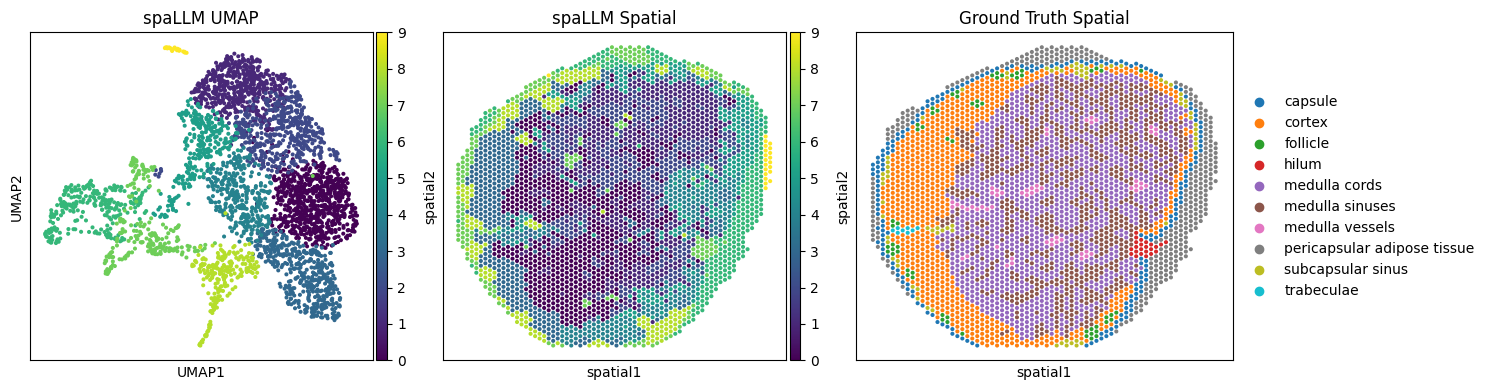

In [8]:
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    homogeneity_score,
    v_measure_score,
    silhouette_score
)

def evaluate_clustering(y_true_series, y_pred_series, features_matrix, name=""):
    # Filter out Exclude/unknown values from verification metrics
    mask = (y_true_series != 'Exclude') & (y_true_series != 'unknown')
    y_true = y_true_series[mask].astype(str)
    y_pred = y_pred_series[mask].astype(str)
    feats = features_matrix[mask]
    
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)
    homogeneity = homogeneity_score(y_true, y_pred)
    v_measure = v_measure_score(y_true, y_pred)
    sil = silhouette_score(feats, y_pred.astype(int) if y_pred.str.isdigit().all() else pd.factorize(y_pred)[0])
    
    print(f"\n=== {name} Clustering Performance ===")
    print(f"ARI: {ari:.4f}")
    print(f"NMI: {nmi:.4f}")
    print(f"AMI: {ami:.4f}")
    print(f"Homogeneity: {homogeneity:.4f}")
    print(f"V-measure: {v_measure:.4f}")
    print(f"Silhouette: {sil:.4f}")
    return {"ARI": ari, "NMI": nmi, "AMI": ami, "Homogeneity": homogeneity, "V-measure": v_measure, "Silhouette": sil}

# Filter out 'unknown' and 'Exclude' labels to calculate the true number of clusters
valid_mask = (adata.obs['ground_truth'] != 'unknown') & (adata.obs['ground_truth'] != 'Exclude')
valid_labels = adata.obs['ground_truth'][valid_mask]
n_clusters = len(np.unique(valid_labels))
print(f"Clustering into {n_clusters} clusters...")

clustering(adata, key='spaLLM', add_key='spaLLM', n_clusters=n_clusters, method='leiden', use_pca=True)

# Evaluate clustering performance
y_true = adata.obs['ground_truth']
spallm_res = evaluate_clustering(y_true, adata.obs['spaLLM'], adata.obsm['spaLLM'], "spaLLM")

# Compute neighbors on spaLLM embedding for UMAP projection
sc.pp.neighbors(adata, use_rep='spaLLM', n_neighbors=10)
sc.tl.umap(adata)

fig, ax_list = plt.subplots(1, 3, figsize=(15, 4))
sc.pl.umap(adata, color='spaLLM', ax=ax_list[0], title='spaLLM UMAP', show=False)
sc.pl.embedding(adata, basis='spatial', color='spaLLM', ax=ax_list[1], title='spaLLM Spatial', show=False)
sc.pl.embedding(adata, basis='spatial', color='ground_truth', ax=ax_list[2], title='Ground Truth Spatial', show=False)
plt.tight_layout()
plt.show()


## 7. Model Loss & Violin Plots

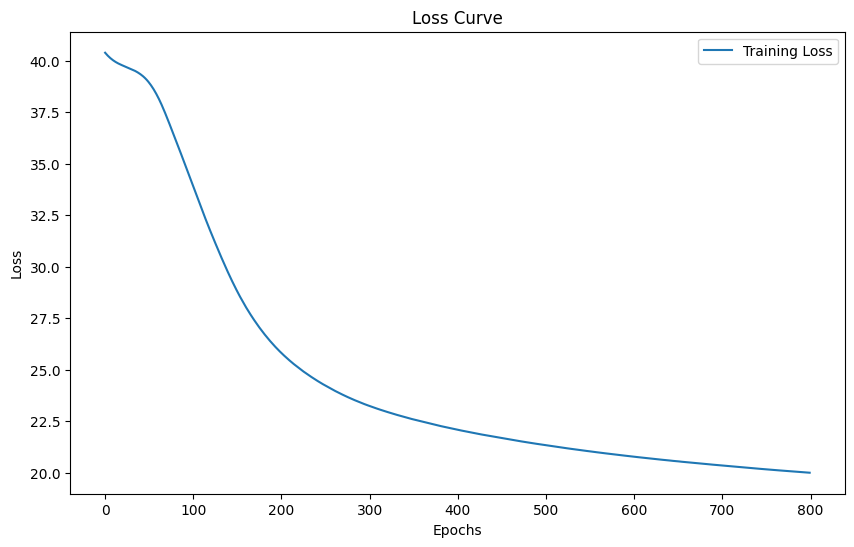

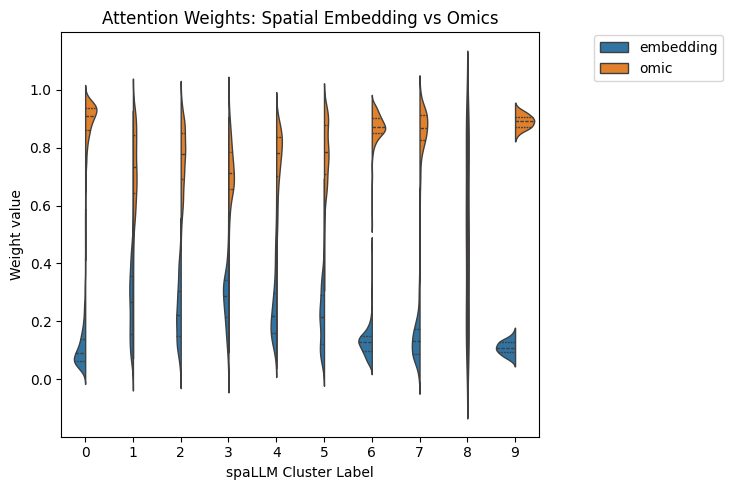

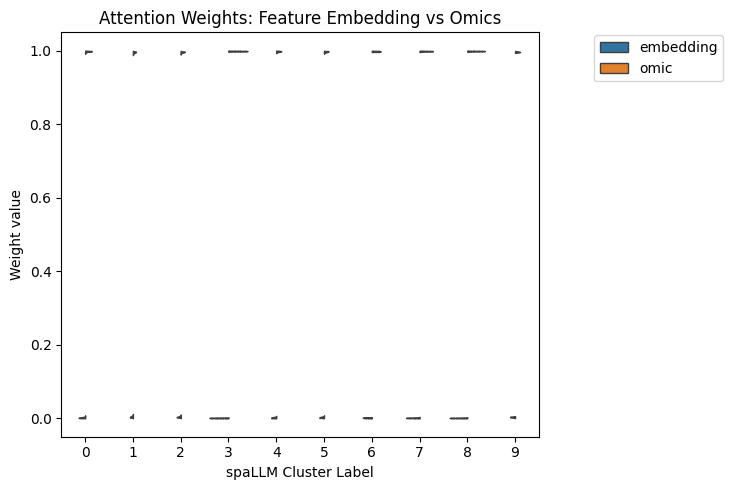

In [9]:
# Plot training loss curve
model.plot_loss()

def plot_violin(adata, alpha_key, title):
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    plt.rcParams['figure.figsize'] = (8, 5)
    df = pd.DataFrame({
        'embedding': adata.obsm[alpha_key][:, 0],
        'omic': adata.obsm[alpha_key][:, 1],
        'label': adata.obs['spaLLM']
    })
    df = df.set_index('label').stack().reset_index()
    df.columns = ['Cluster_Label', 'Modality', 'Weight value']
    ax = sns.violinplot(data=df, x='Cluster_Label', y='Weight value', hue='Modality', split=True, inner='quart', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('spaLLM Cluster Label')
    ax.legend(bbox_to_anchor=(1.4, 1.01), loc='upper right')
    plt.tight_layout(w_pad=0.05)
    plt.show()

# Plot violin plots for attention weights
plot_violin(adata, 'alpha_att1', 'Attention Weights: Spatial Embedding vs Omics')
plot_violin(adata, 'alpha_att2', 'Attention Weights: Feature Embedding vs Omics')
